Clustering VidProM Prompts

In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

In [3]:
df = pd.read_csv("../data/VidProM_unique.csv")
sample = df.sample(100_000, random_state=42).reset_index(drop=True)

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sample['prompt'].tolist(), show_progress_bar=True, batch_size=256)

print(f"embeddings shape: {embeddings.shape}")

np.save('../data/embeddings_100k.npy', embeddings)
sample.to_csv('../data/sample_100k.csv', index=False)
print("saved!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/391 [00:00<?, ?it/s]

embeddings shape: (100000, 384)
saved!


In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [12]:
# Load (if you restarted the laptop, no need to recalculate)
embeddings = np.load('../data/embeddings_100k.npy')

# PCA: 384 -> 50 (for KMeans) and -> 2 (for visualisation)
pca50 = PCA(n_components=50, random_state=42)
emb_50d = pca50.fit_transform(embeddings)
print(f"Explained variance (50 dims): {pca50.explained_variance_ratio_.sum():.2%}")

pca2 = PCA(n_components=2, random_state=42)
emb_2d = pca2.fit_transform(embeddings)

Explained variance (50 dims): 53.57%


Elbow method:

k=3, inertia=43329
k=4, inertia=42309
k=5, inertia=41443
k=6, inertia=40792
k=7, inertia=40251
k=8, inertia=39761
k=9, inertia=39315
k=10, inertia=38897
k=11, inertia=38514
k=12, inertia=38143
k=13, inertia=37728
k=14, inertia=37423
k=15, inertia=37103
k=16, inertia=36828
k=17, inertia=36532
k=18, inertia=36269
k=19, inertia=36039
k=20, inertia=35810


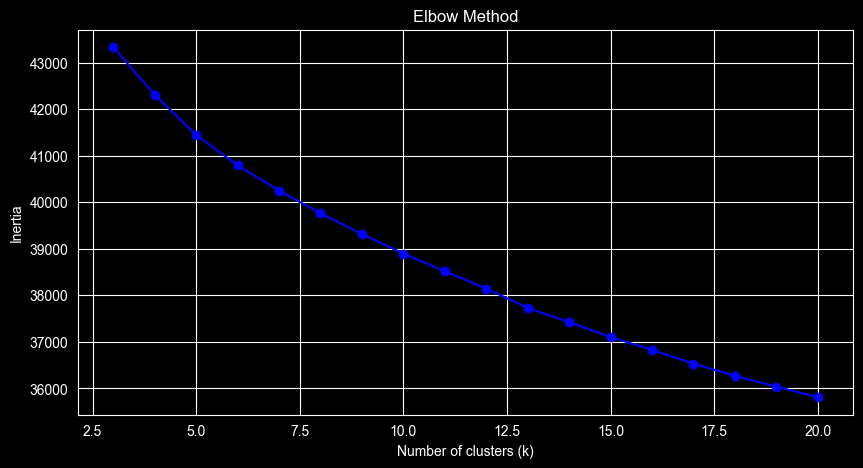

In [13]:
inertias = []
K_range = range(3, 21)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(emb_50d)
    inertias.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.0f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title('Elbow Method')
plt.savefig('../data/elbow.png', dpi=150)
plt.show()

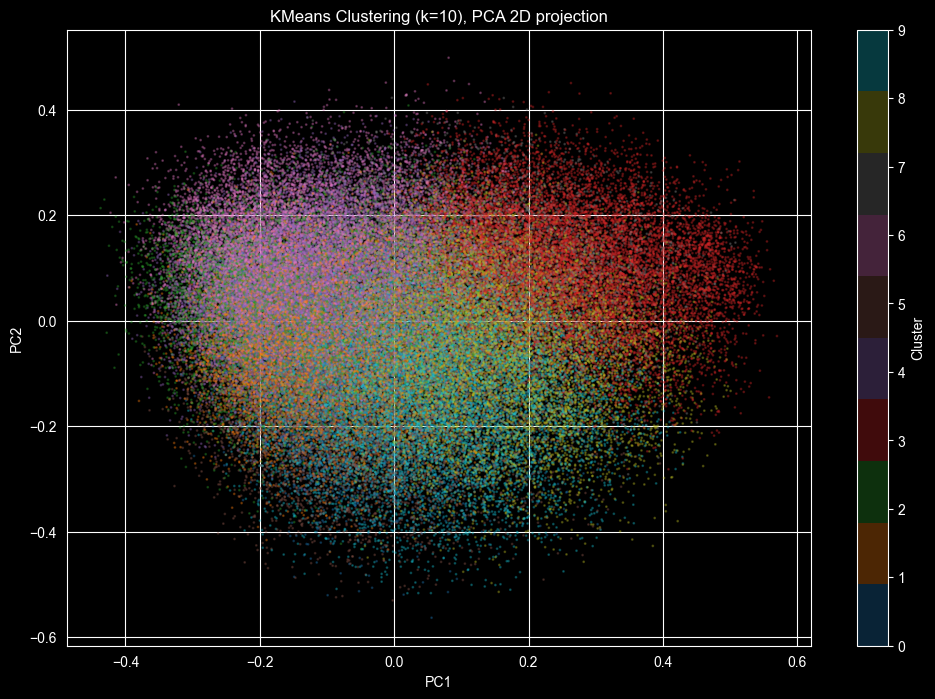


Cluster 0 (3924 prompts)
  - video theme  Message: Pigeon00b (Font: RETRO)  
  - girl fight with eval dragon  Message: 1 Attachment  
  - a man smiling  Message: 1 Attachment  
  - make me a logo with the name patrao  
  - viking runic carved motifs, ancient art, museum display  Message: The Stone (Font: MODERN)  
  - Attached is the text of the AI Technology Aler  Message: 1 Attachment  
  - sleep girl  Message: 1 Attachment  
  - BLUE SKY WITH WHITE CLOUDS  Message: CDATA (Font: COMICS)  
  - image:retouch_2024021914011823.jpg  
  - Starry Night by Van Gogh, painting, large moon, /animate, -w0.7  Message: SEAN BOON (Font: MODERN)  

Cluster 1 (9553 prompts)
  - dancers of peruvian folklore dancing Hualas in a festival, 16 mm,  realism, -zoom in, -gs24, -motion
  - Wearing a robe, the free traveler often walks in the mountains and rivers, holding a bag in hand, sm
  - Salvador Dali water  
  - jesus and many ancient warriors dressed in white. panoramic view  
  - make gojo satoru and

In [14]:
# final clusterization with k=10
k = 10
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(emb_50d)

sample = pd.read_csv('../data/sample_100k.csv')
sample['cluster'] = labels

# scatter plot 2D
plt.figure(figsize=(12, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', s=1, alpha=0.3)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans Clustering (k={k}), PCA 2D projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('../data/clusters_scatter.png', dpi=150)
plt.show()

for c in range(k):
    prompts = sample[sample['cluster'] == c]['prompt']
    print(f"\n{'='*60}")
    print(f"Cluster {c} ({len(prompts)} prompts)")
    print(f"{'='*60}")
    for p in prompts.sample(min(10, len(prompts)), random_state=42):
        print(f"  - {p[:100]}")

### Clustering Summary

  | Cluster | Count | Theme |
  |---------|-------|-------|
  | 0 | 3,924 | Discord messages/attachments (junk) |
  | 1 | 9,553 | Epic/historical scenes (warriors, mythology, religion) |
  | 2 | 10,132 | Animals/creatures (cats, owls, rabbits, cartoon animals) |
  | 3 | 12,691 | Cinematic/aesthetic (8K, realism, cinematic style, aspect ratios) |
  | 4 | 15,700 | Mixed/general (diverse prompts, no clear theme) |
  | 5 | 8,929 | Women/girls (female characters, portraits) |
  | 6 | 9,636 | Men/characters (male characters, celebrities) |
  | 7 | 7,478 | Horror/dark (horror, sci-fi, dark atmosphere) |
  | 8 | 10,694 | Animation/cartoon (anime, 3D, cartoon styles) |
  | 9 | 11,263 | Nature/landscapes (rain, mountains, forests, wildlife) |

  Key findings:
  - 10 clusters capture distinct thematic groups in video generation prompts
  - Nature, animals, and human characters dominate user requests
  - Cluster 0 reveals Discord metadata leaking into prompts (data quality issue)
  - Cluster 3 shows users actively using technical parameters (-ar, -motion, 8K)
  - Gender split: separate clusters for male (6) and female (5) characters
  - PCA with 50 components explains 53.57% of variance

In [15]:
sample.to_csv('../data/sample_clustered.csv', index=False)
print(f"Saved {len(sample)} prompts with cluster labels")
print(sample['cluster'].value_counts().sort_index())

Saved 100000 prompts with cluster labels
cluster
0     3924
1     9553
2    10132
3    12691
4    15700
5     8929
6     9636
7     7478
8    10694
9    11263
Name: count, dtype: int64
